In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Conv1D, BatchNormalization,
                                      Dropout, Dense, Flatten,
                                      Multiply, GlobalAveragePooling1D,
                                      Activation, Reshape)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

In [2]:
df = pd.read_csv(r"D:\Datasets\BEED_Data.csv")
print("Dataset shape:", df.shape)
print("Class distribution:\n", df['y'].value_counts().sort_index())

Dataset shape: (8000, 17)
Class distribution:
 y
0    2000
1    2000
2    2000
3    2000
Name: count, dtype: int64


In [3]:
X = df.drop('y', axis=1).values   # (8000, 16)
y = df['y'].values                 # (8000,)

In [4]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [5]:
y = to_categorical(y, num_classes=4)

In [6]:
X = X.reshape(-1, 16, 1)

In [7]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30,
                                    random_state=42, stratify=np.argmax(y, axis=1))
X_val, X_test, y_val, y_test     = train_test_split(X_temp, y_temp, test_size=0.50,
                                    random_state=42, stratify=np.argmax(y_temp, axis=1))

print(f"\nTrain: {X_train.shape[0]} | Val: {X_val.shape[0]} | Test: {X_test.shape[0]}")


Train: 5600 | Val: 1200 | Test: 1200


In [9]:
def channel_attention(x, ratio=4):
    """
    Channel Attention:
    Learns WHICH features (channels) are important.
    """
    filters = x.shape[-1]

    # Squeeze: GlobalAveragePooling → dense → dense → sigmoid
    gap = GlobalAveragePooling1D()(x)                          # (batch, filters)
    fc1 = Dense(filters // ratio, activation='relu')(gap)      # Compress
    fc2 = Dense(filters, activation='sigmoid')(fc1)            # Expand back
    fc2 = Reshape((1, filters))(fc2)                           # (batch, 1, filters)

    # Scale: multiply attention weights with input
    return Multiply()([x, fc2])


def spatial_attention(x):
    """
    Spatial Attention:
    Learns WHERE (which time steps) to focus.
    """
    # Average across channel dimension
    avg = tf.reduce_mean(x, axis=-1, keepdims=True)            # (batch, steps, 1)
    attention = Conv1D(1, kernel_size=3, padding='same',
                       activation='sigmoid')(avg)               # (batch, steps, 1)
    return Multiply()([x, attention])

In [12]:
def build_attention_cnn(input_shape=(16, 1), num_classes=4):

    inputs = Input(shape=input_shape)

    # --- Block 1: Lightweight CNN ---
    x = Conv1D(32, kernel_size=3, padding='same', activation='relu')(inputs)
    x = BatchNormalization()(x)
    x = Dropout(0.2)(x)

    # --- Block 2: CNN + Channel Attention ---
    x = Conv1D(64, kernel_size=3, padding='same', activation='relu')(x)
    x = BatchNormalization()(x)
    x = channel_attention(x, ratio=4)                 # ← Channel Attention
    x = Dropout(0.2)(x)

    # --- Block 3: CNN + Spatial Attention ---
    x = Conv1D(32, kernel_size=3, padding='same', activation='relu')(x)
    x = BatchNormalization()(x)
    x = spatial_attention(x)                           # ← Spatial Attention
    x = Dropout(0.2)(x)

    # --- Classifier Head ---
    x = GlobalAveragePooling1D()(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.3)(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs, name='Attention_Lightweight_CNN')
    return model

model = build_attention_cnn()
model.summary()

Model: "Attention_Lightweight_CNN"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 16, 1)]      0           []                               
                                                                                                  
 conv1d (Conv1D)                (None, 16, 32)       128         ['input_1[0][0]']                
                                                                                                  
 batch_normalization (BatchNorm  (None, 16, 32)      128         ['conv1d[0][0]']                 
 alization)                                                                                       
                                                                                                  
 dropout (Dropout)              (None, 16, 32)       0           ['batch_n

In [13]:
total_params = model.count_params()
print(f"\n✅ Total Parameters: {total_params:,}  ← Lightweight!")


✅ Total Parameters: 17,528  ← Lightweight!


In [14]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=15,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=7, min_lr=1e-6, verbose=1)
]

print("\nTraining model...")
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)



Training model...
Epoch 1/100
175/175 [==============================] - 11s 14ms/step - loss: 0.9086 - accuracy: 0.5905 - val_loss: 1.0238 - val_accuracy: 0.4950 - lr: 0.0010
Epoch 2/100
175/175 [==============================] - 2s 9ms/step - loss: 0.7379 - accuracy: 0.6459 - val_loss: 1.0168 - val_accuracy: 0.5100 - lr: 0.0010
Epoch 3/100
175/175 [==============================] - 2s 9ms/step - loss: 0.6954 - accuracy: 0.6604 - val_loss: 0.7624 - val_accuracy: 0.5833 - lr: 0.0010
Epoch 4/100
175/175 [==============================] - 2s 10ms/step - loss: 0.6760 - accuracy: 0.6696 - val_loss: 0.6078 - val_accuracy: 0.7050 - lr: 0.0010
Epoch 5/100
175/175 [==============================] - 2s 10ms/step - loss: 0.6531 - accuracy: 0.6857 - val_loss: 0.6177 - val_accuracy: 0.7183 - lr: 0.0010
Epoch 6/100
175/175 [==============================] - 2s 9ms/step - loss: 0.6296 - accuracy: 0.7000 - val_loss: 0.5599 - val_accuracy: 0.7283 - lr: 0.0010
Epoch 7/100
175/175 [====================

In [16]:
print("\n" + "=" * 50)
print("EVALUATION ON TEST SET")
print("=" * 50)

loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy : {acc * 100:.2f}%")
print(f"Test Loss     : {loss:.4f}")

y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
y_true = np.argmax(y_test, axis=1)

CLASS_NAMES = ['Healthy', 'Generalized\nSeizure', 'Focal\nSeizure', 'Seizure\nEvent']

print("\nClassification Report:")
print(classification_report(y_true, y_pred,
      target_names=['Healthy', 'Gen.Seizure', 'Focal Seizure', 'Seizure Event']))


EVALUATION ON TEST SET
Test Accuracy : 88.25%
Test Loss     : 0.2914

Classification Report:
               precision    recall  f1-score   support

      Healthy       1.00      1.00      1.00       300
  Gen.Seizure       0.96      0.87      0.91       300
Focal Seizure       0.83      0.83      0.83       300
Seizure Event       0.76      0.83      0.79       300

     accuracy                           0.88      1200
    macro avg       0.89      0.88      0.88      1200
 weighted avg       0.89      0.88      0.88      1200



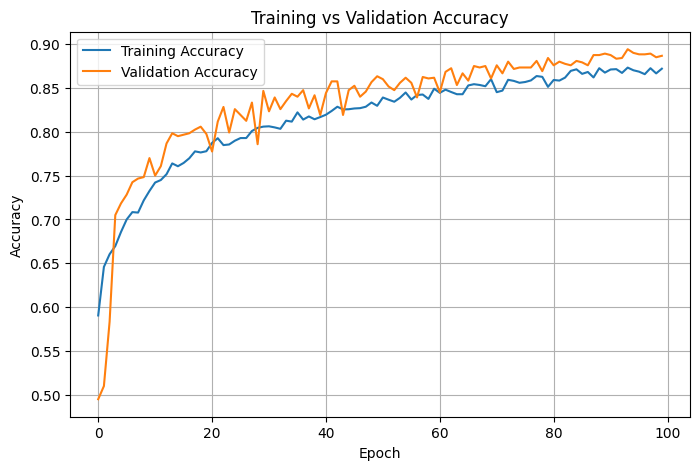

In [23]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.grid(True)

plt.show()

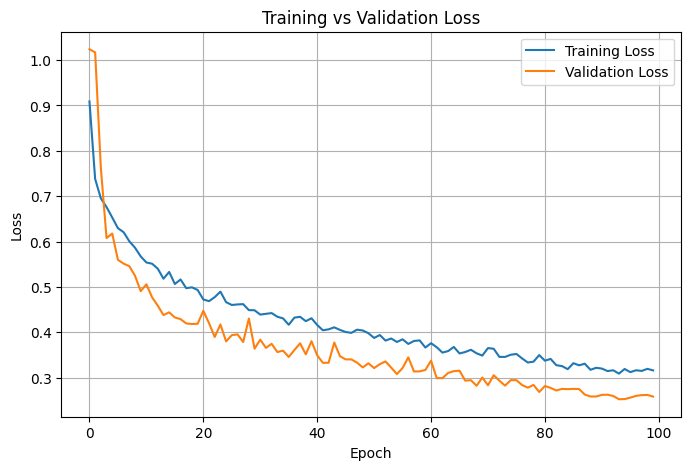

In [24]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.grid(True)

plt.show()